# Projet 3 — Identifier les facteurs qui influencent les performances commerciales

**Source :** LDA Advisory — 12 Projets pour devenir Data Analyst  
**Dataset :** Sample Superstore  
**Outils :** Python · pandas · matplotlib · seaborn · scipy

---

## Contexte métier

> Une entreprise souhaite comprendre les interactions entre ses produits, ses performances régionales et ses marges pour **optimiser sa stratégie commerciale**.

## Objectif analytique

Analyser les relations **quali-quali**, **quali-quanti** et **quanti-quanti** pour détecter les facteurs clés qui influencent les ventes et la rentabilité.

## Plan d'analyse

| Étape | Type d'analyse | Variables |
|-------|---------------|----------|
| 1 | Chargement & exploration | Toutes |
| 2 | **Quali-Quali** | Catégorie × Région, Segment × Mode de livraison |
| 3 | **Quali-Quanti** | Région/Catégorie/Segment × Ventes/Profit |
| 4 | **Quanti-Quanti** | Ventes, Profit, Discount, Quantité |
| 5 | Synthèse & recommandations | — |

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- Style global ---
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})

print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement & Exploration des données

In [2]:
df = pd.read_csv('Sample_-_Superstore.csv', encoding='latin1', parse_dates=['Order Date', 'Ship Date'])

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Période    : {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
print(f'Doublons   : {df.duplicated().sum()}')
print(f'Valeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Dimensions : 9,994 lignes × 21 colonnes
Période    : 2014-01-03 → 2017-12-30
Doublons   : 0
Valeurs manquantes :
Series([], dtype: int64)


In [3]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [4]:
# Aperçu des variables qualitatives
cat_cols = ['Segment', 'Ship Mode', 'Region', 'Category', 'Sub-Category']
for col in cat_cols:
    print(f'{col:15s}: {df[col].unique().tolist()}')

Segment        : ['Consumer', 'Corporate', 'Home Office']
Ship Mode      : ['Second Class', 'Standard Class', 'First Class', 'Same Day']
Region         : ['South', 'West', 'Central', 'East']
Category       : ['Furniture', 'Office Supplies', 'Technology']
Sub-Category   : ['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper', 'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']


In [5]:
# Statistiques descriptives des variables quantitatives
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


**Observations préliminaires :**
- Les **ventes** sont très asymétriques (max = 22 638 $ vs médiane = 54 $) → présence de grandes commandes.
- Le **profit** peut être négatif (min = -6 600 $) → certaines lignes sont déficitaires.
- Le **discount** va de 0 à 80 % → fort impact potentiel sur la rentabilité.

---
## 2. Analyse Quali-Quali

> **Objectif :** Comprendre comment deux variables catégorielles se répartissent ensemble.  
> **Outils :** Tableaux croisés (crosstab), heatmaps, bar charts empilés.

### 2.1 Répartition des commandes : Catégorie × Région

In [6]:
ct = pd.crosstab(df['Category'], df['Region'])
ct_pct = pd.crosstab(df['Category'], df['Region'], normalize='index').round(3) * 100

print('=== Effectifs ===' )
print(ct)
print('\n=== % par ligne (répartition régionale de chaque catégorie) ===')
print(ct_pct)

=== Effectifs ===
Region           Central  East  South  West
Category                                   
Furniture            481   601    332   707
Office Supplies     1422  1712    995  1897
Technology           420   535    293   599

=== % par ligne (répartition régionale de chaque catégorie) ===
Region           Central  East  South  West
Category                                   
Furniture           22.7  28.3   15.7  33.3
Office Supplies     23.6  28.4   16.5  31.5
Technology          22.7  29.0   15.9  32.4


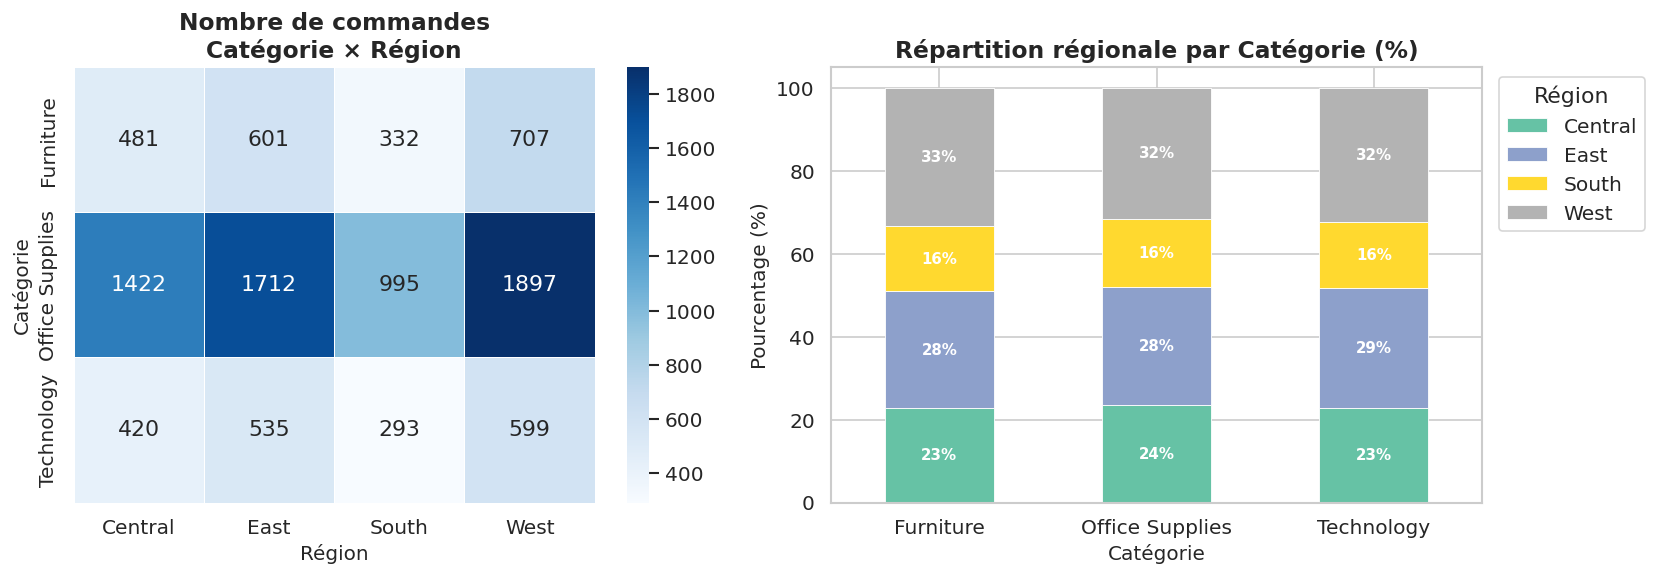

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap des effectifs
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0])
axes[0].set_title('Nombre de commandes\nCatégorie × Région')
axes[0].set_xlabel('Région'); axes[0].set_ylabel('Catégorie')

# Bar chart empilé (% par catégorie)
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1].set_title('Répartition régionale par Catégorie (%)')
axes[1].set_xlabel('Catégorie'); axes[1].set_ylabel('Pourcentage (%)')
axes[1].legend(title='Région', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    h = bar.get_height()
    if h > 5:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_y() + h/2, f'{h:.0f}%',
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_qualiQuali_cat_region.png', bbox_inches='tight')
plt.show()

**Lecture :** La répartition régionale est **homogène entre catégories** (~30% West dans chaque). La région **West** domine systématiquement, ce qui suggère un marché plus développé — à explorer dans l'analyse quali-quanti.

### 2.2 Segment client × Mode de livraison

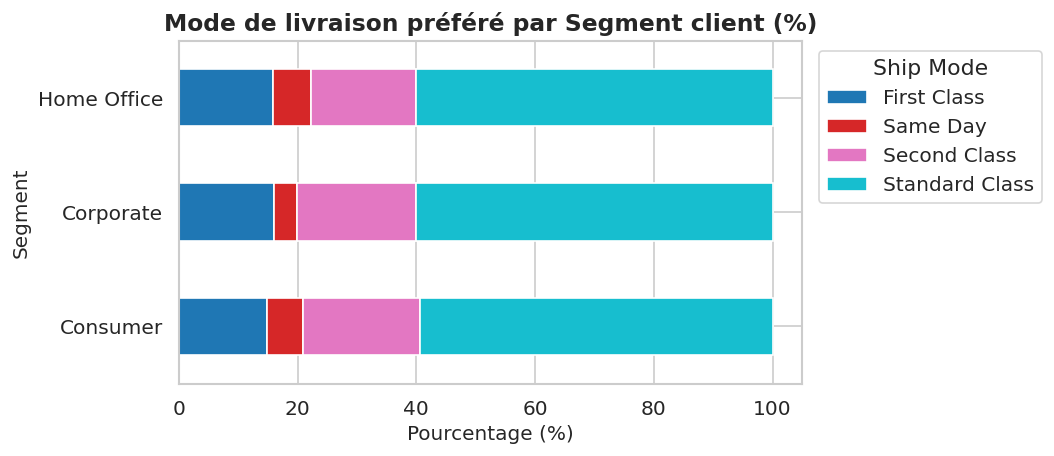

Ship Mode    First Class  Same Day  Second Class  Standard Class
Segment                                                         
Consumer            14.8       6.1          19.6            59.4
Corporate           16.1       3.8          20.2            60.0
Home Office         15.9       6.3          17.7            60.1


In [8]:
ct2 = pd.crosstab(df['Segment'], df['Ship Mode'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(9, 4))
ct2.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Mode de livraison préféré par Segment client (%)')
ax.set_xlabel('Pourcentage (%)')
ax.set_ylabel('Segment')
ax.legend(title='Ship Mode', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('fig_qualiQuali_segment_ship.png', bbox_inches='tight')
plt.show()

print(ct2.round(1))

**Lecture :** Le mode **Standard Class** est dominant dans tous les segments (~60%). Les clients **Home Office** utilisent légèrement plus le **Same Day** — potentiellement plus sensibles à l'urgence.

---
## 3. Analyse Quali-Quanti

> **Objectif :** Comparer les distributions d'une variable numérique selon les groupes d'une variable catégorielle.  
> **Outils :** Boxplots, bar charts de moyennes, scatter avec couleur.

### 3.1 Profit moyen par Région

In [9]:
profit_region = df.groupby('Region')['Profit'].agg(['mean', 'median', 'sum', 'count']).round(2)
profit_region.columns = ['Moyenne', 'Médiane', 'Total', 'Nb lignes']
profit_region = profit_region.sort_values('Moyenne', ascending=False)
print(profit_region)

         Moyenne  Médiane      Total  Nb lignes
Region                                         
West       33.85    11.17  108418.45       3203
East       32.14     8.17   91522.78       2848
South      28.86     9.07   46749.43       1620
Central    17.09     5.18   39706.36       2323


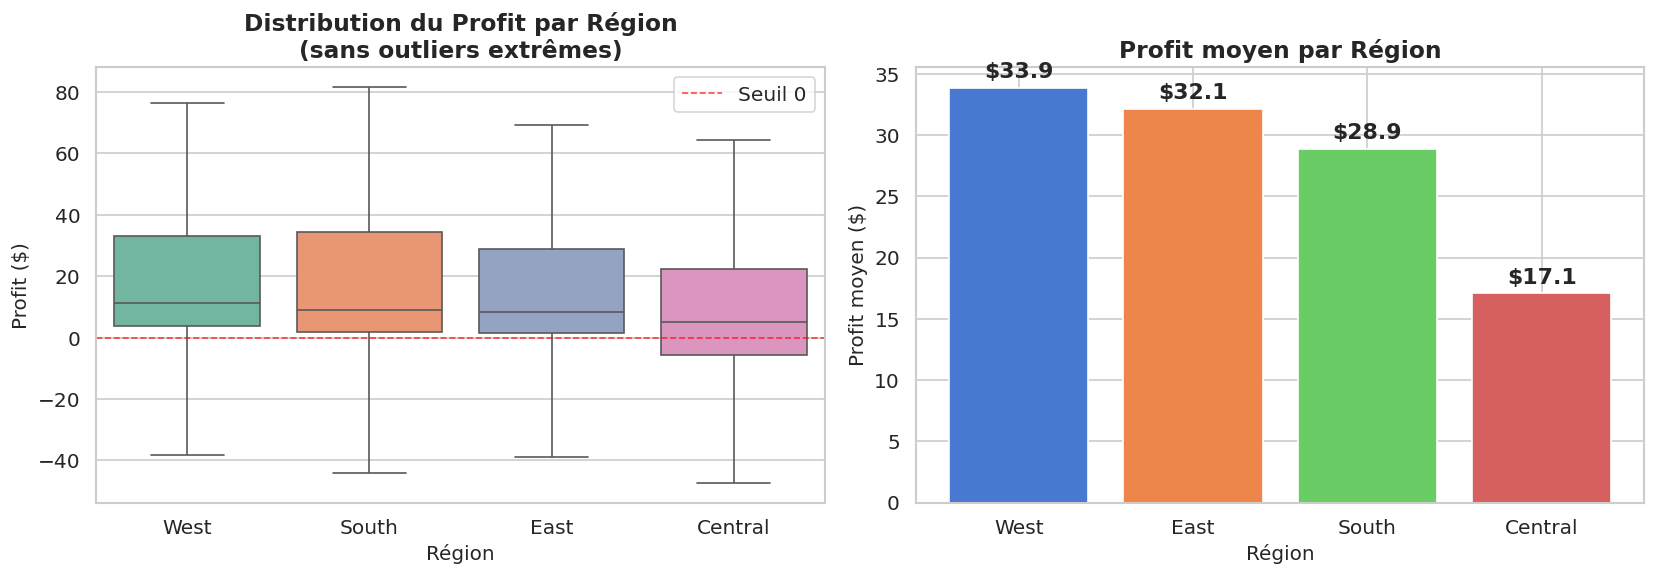

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
order_region = df.groupby('Region')['Profit'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Region', y='Profit', order=order_region,
            palette='Set2', showfliers=False, ax=axes[0])
axes[0].set_title('Distribution du Profit par Région\n(sans outliers extrêmes)')
axes[0].set_xlabel('Région'); axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Seuil 0')
axes[0].legend()

# Bar chart profit moyen
colors = [PALETTE[i] for i in range(len(profit_region))]
axes[1].bar(profit_region.index, profit_region['Moyenne'], color=colors, edgecolor='white')
axes[1].set_title('Profit moyen par Région')
axes[1].set_xlabel('Région'); axes[1].set_ylabel('Profit moyen ($)')
for i, (reg, row) in enumerate(profit_region.iterrows()):
    axes[1].text(i, row['Moyenne'] + 0.5, f"${row['Moyenne']:.1f}",
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_qualiQuanti_profit_region.png', bbox_inches='tight')
plt.show()

**Lecture :** La région **West** génère le profit moyen le plus élevé (~31 $), tandis que la région **Central** est la moins rentable (~21 $). Toutes les médianes restent positives, mais les boîtes à moustaches révèlent une grande variabilité interne.

### 3.2 Ventes & Profit par Catégorie

In [11]:
cat_perf = df.groupby('Category')[['Sales', 'Profit']].agg(['mean', 'sum']).round(2)
cat_perf.columns = ['Sales_mean', 'Sales_sum', 'Profit_mean', 'Profit_sum']
cat_perf['Marge (%)'] = (cat_perf['Profit_sum'] / cat_perf['Sales_sum'] * 100).round(2)
print(cat_perf)

                 Sales_mean  Sales_sum  Profit_mean  Profit_sum  Marge (%)
Category                                                                  
Furniture            349.83  741999.80         8.70    18451.27       2.49
Office Supplies      119.32  719047.03        20.33   122490.80      17.04
Technology           452.71  836154.03        78.75   145454.95      17.40


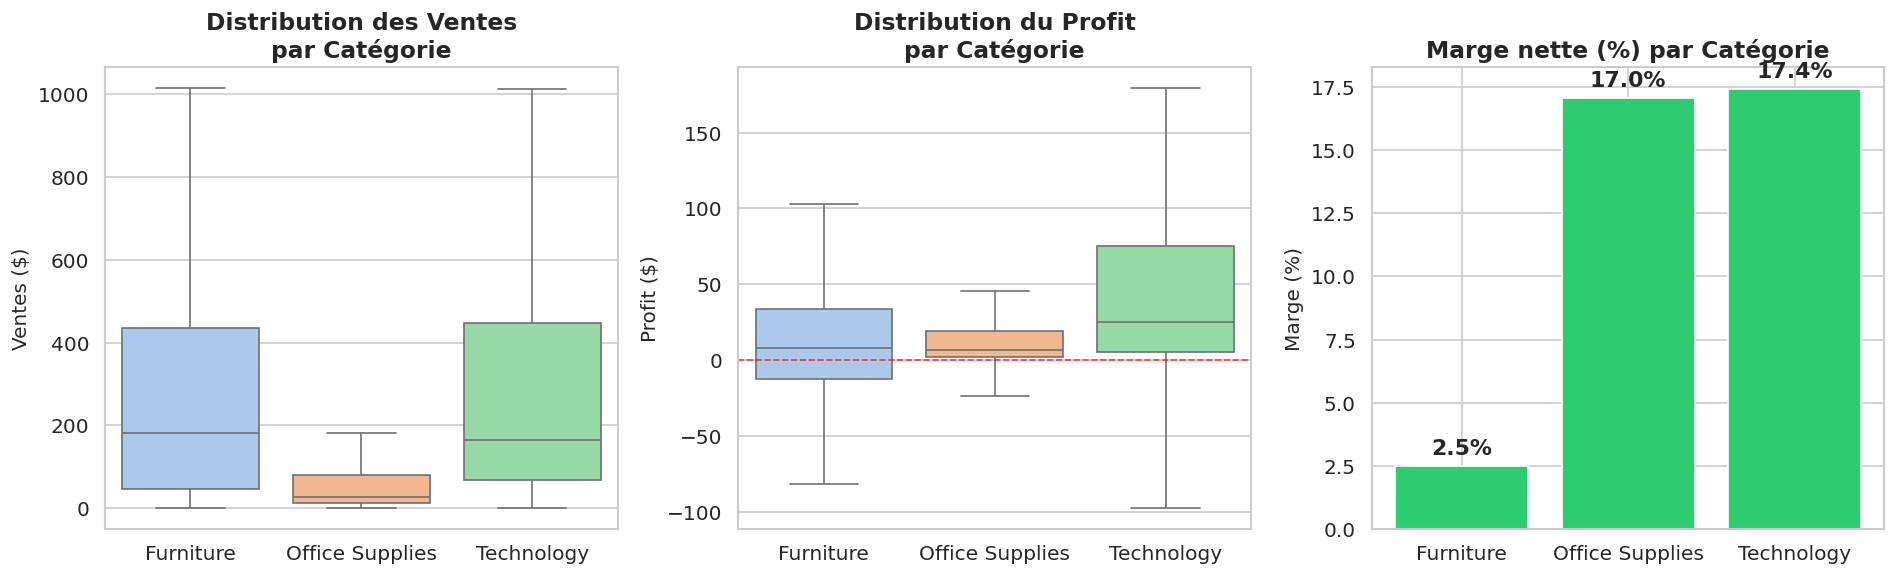

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot Sales
sns.boxplot(data=df, x='Category', y='Sales', palette='pastel', showfliers=False, ax=axes[0])
axes[0].set_title('Distribution des Ventes\npar Catégorie')
axes[0].set_ylabel('Ventes ($)'); axes[0].set_xlabel('')

# Boxplot Profit
sns.boxplot(data=df, x='Category', y='Profit', palette='pastel', showfliers=False, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('Distribution du Profit\npar Catégorie')
axes[1].set_ylabel('Profit ($)'); axes[1].set_xlabel('')

# Marge nette
colors = ['#e74c3c' if m < 0 else '#2ecc71' for m in cat_perf['Marge (%)']]
axes[2].bar(cat_perf.index, cat_perf['Marge (%)'], color=colors, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Marge nette (%) par Catégorie')
axes[2].set_ylabel('Marge (%)')
for i, (cat, row) in enumerate(cat_perf.iterrows()):
    axes[2].text(i, row['Marge (%)'] + 0.3, f"{row['Marge (%)']:.1f}%",
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_qualiQuanti_cat_perf.png', bbox_inches='tight')
plt.show()

**Lecture :** Le **Furniture** génère des ventes élevées mais une marge très faible (~2.5%). La catégorie **Technology** est la plus rentable (~17%). **Office Supplies** représente un volume élevé à marge modérée.

### 3.3 Zoom sur les sous-catégories : Top rentables vs déficitaires

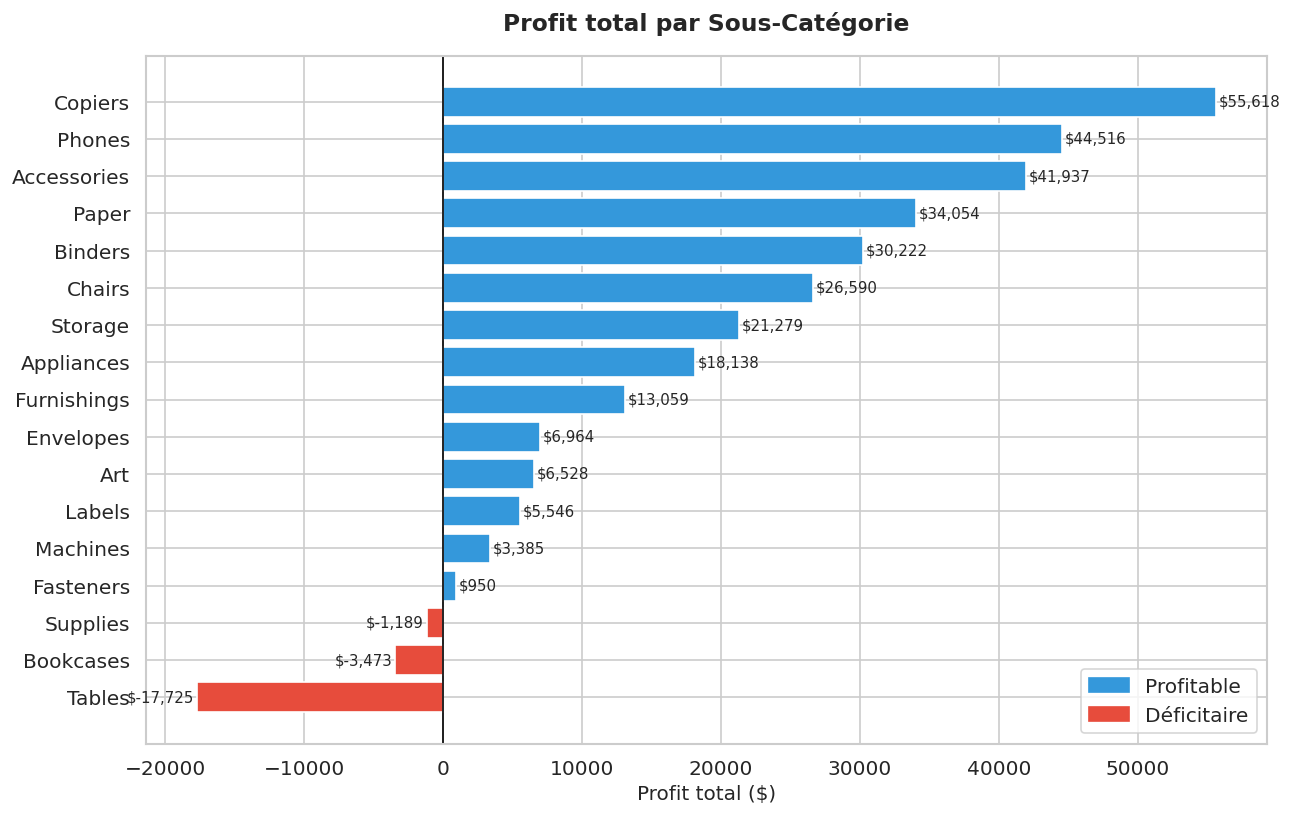

In [13]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#e74c3c' if v < 0 else '#3498db' for v in subcat_profit.values]
bars = ax.barh(subcat_profit.index, subcat_profit.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Profit total par Sous-Catégorie', pad=15)
ax.set_xlabel('Profit total ($)')

for bar, val in zip(bars, subcat_profit.values):
    offset = 200 if val >= 0 else -200
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha=ha, fontsize=9)

# Légende
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Profitable'), Patch(color='#e74c3c', label='Déficitaire')],
          loc='lower right')

plt.tight_layout()
plt.savefig('fig_qualiQuanti_subcat_profit.png', bbox_inches='tight')
plt.show()

**⚠️ Insight majeur :** Les **Tables** et **Bookcases** (Furniture) sont nettement **déficitaires**. Ces produits détruisent de la valeur malgré des ventes parfois importantes → piste d'optimisation prioritaire.

### 3.4 Impact de la remise (Discount) sur le Profit par Catégorie

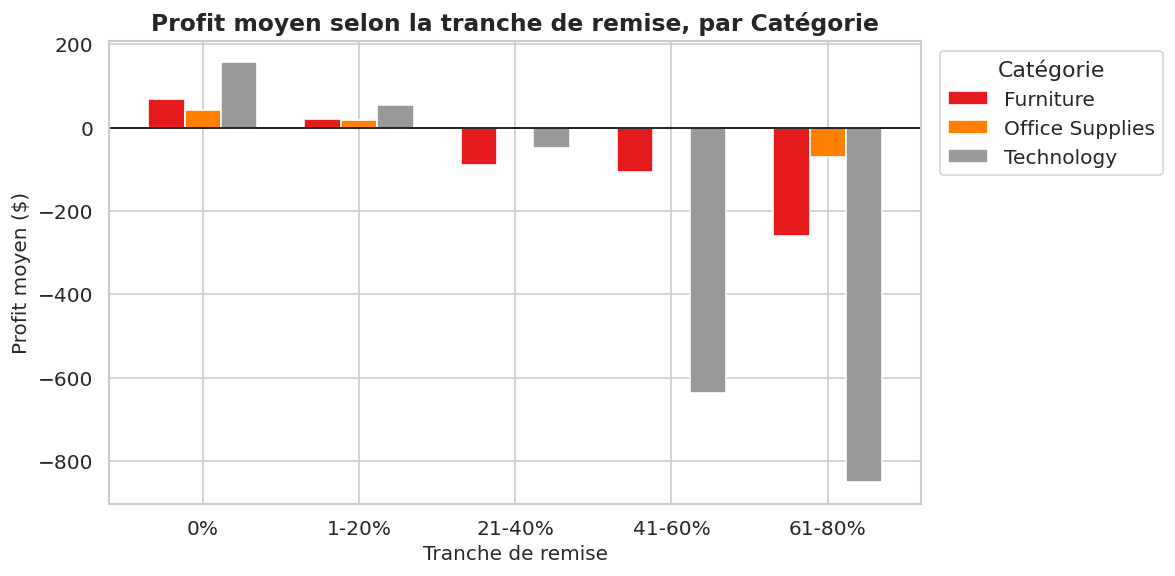

In [14]:
# Créer des tranches de discount
bins = [-0.01, 0, 0.2, 0.4, 0.6, 0.81]
labels = ['0%', '1-20%', '21-40%', '41-60%', '61-80%']
df['Discount_bin'] = pd.cut(df['Discount'], bins=bins, labels=labels)

disc_profit = df.groupby(['Discount_bin', 'Category'], observed=True)['Profit'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
disc_profit.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white', width=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Profit moyen selon la tranche de remise, par Catégorie')
ax.set_xlabel('Tranche de remise')
ax.set_ylabel('Profit moyen ($)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Catégorie', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('fig_qualiQuanti_discount_profit.png', bbox_inches='tight')
plt.show()

**Lecture :** Au-delà de **20% de remise**, le profit moyen devient négatif dans toutes les catégories. Le **Furniture** est particulièrement vulnérable aux remises élevées.

---
## 4. Analyse Quanti-Quanti

> **Objectif :** Mesurer et visualiser les relations linéaires entre variables numériques.  
> **Outils :** Scatter plots, heatmap de corrélation, corrélation de Pearson.

### 4.1 Matrice de corrélation

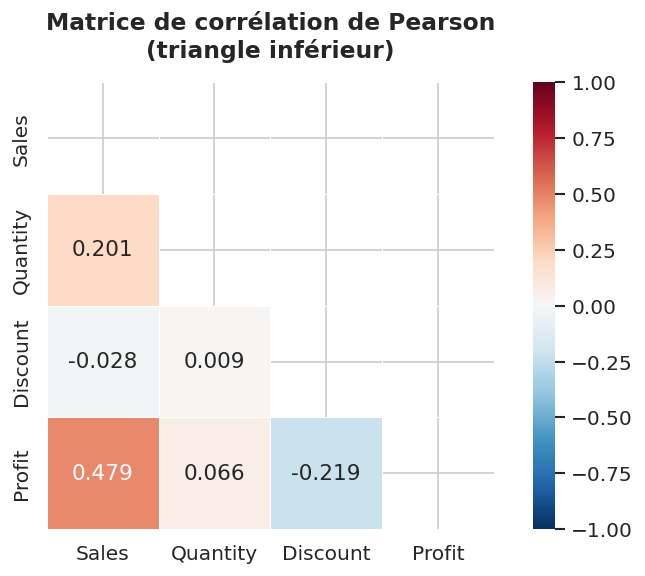

          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000


In [15]:
num_vars = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[num_vars].corr(method='pearson').round(3)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masquer le triangle supérieur
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            mask=mask, ax=ax, annot_kws={'size': 13})
ax.set_title('Matrice de corrélation de Pearson\n(triangle inférieur)', pad=15)

plt.tight_layout()
plt.savefig('fig_quantiQuanti_heatmap_corr.png', bbox_inches='tight')
plt.show()

print(corr_matrix)

### 4.2 Scatter plots : Relations clés

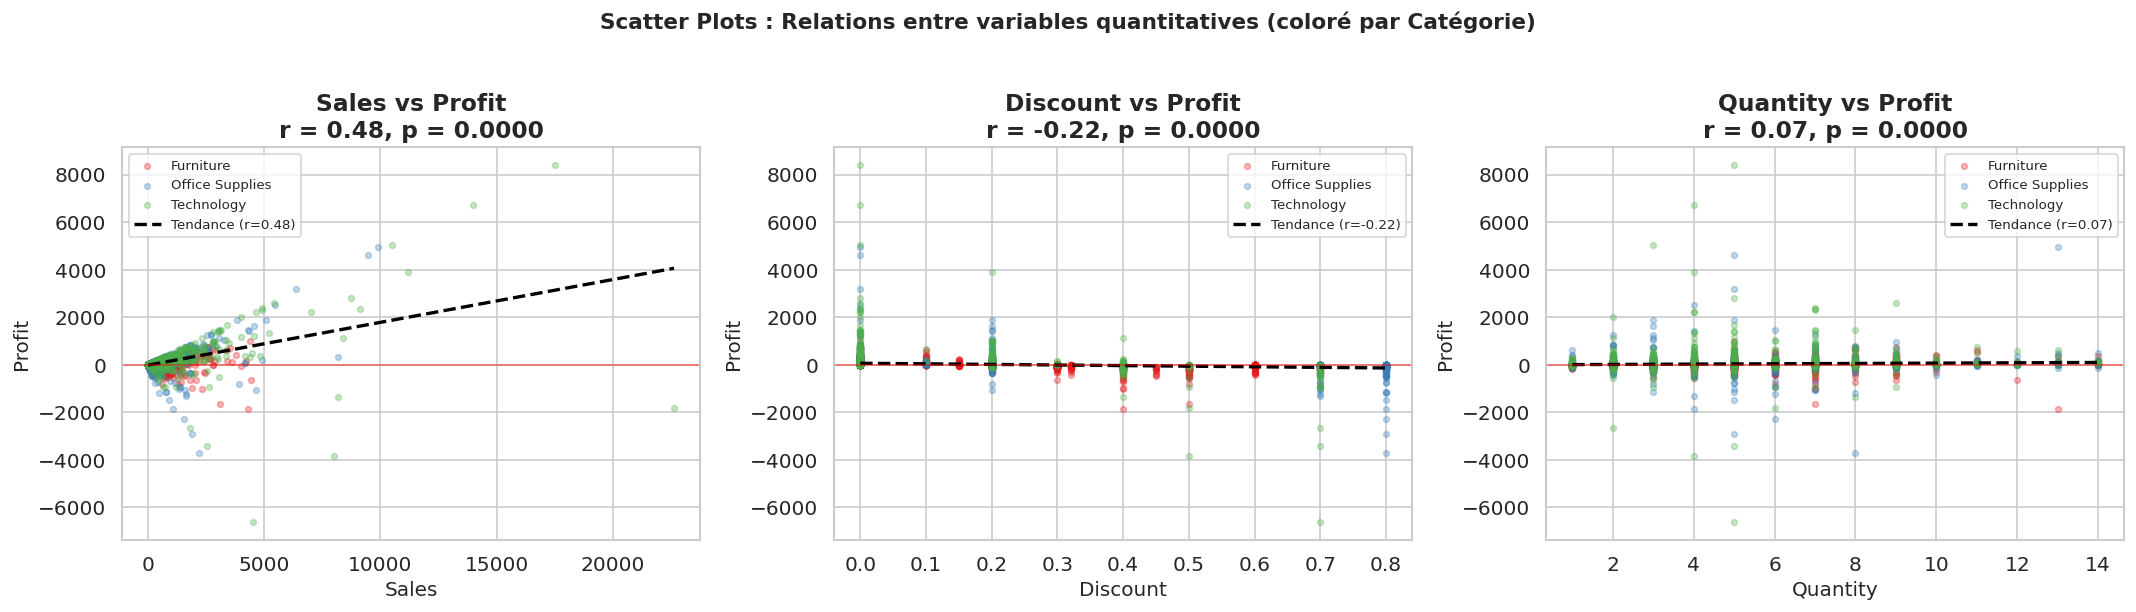

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ('Sales', 'Profit', 'Category'),
    ('Discount', 'Profit', 'Category'),
    ('Quantity', 'Profit', 'Category'),
]

for ax, (x, y, hue) in zip(axes, pairs):
    categories = df[hue].unique()
    palette = sns.color_palette('Set1', n_colors=len(categories))
    for i, cat in enumerate(categories):
        sub = df[df[hue] == cat]
        ax.scatter(sub[x], sub[y], alpha=0.3, s=12, color=palette[i], label=cat)
    
    # Ligne de tendance globale
    slope, intercept, r, p, _ = stats.linregress(df[x], df[y])
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xline, slope * xline + intercept, color='black', linewidth=2, linestyle='--', label=f'Tendance (r={r:.2f})')
    
    ax.axhline(0, color='red', linewidth=1, alpha=0.5)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.2f}, p = {p:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Scatter Plots : Relations entre variables quantitatives (coloré par Catégorie)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_quantiQuanti_scatter.png', bbox_inches='tight')
plt.show()

### 4.3 Tests de corrélation (Pearson + Spearman)

In [17]:
pairs_test = [('Sales', 'Profit'), ('Discount', 'Profit'), ('Quantity', 'Profit'), ('Discount', 'Sales')]

results = []
for x, y in pairs_test:
    r_p, p_p = stats.pearsonr(df[x], df[y])
    r_s, p_s = stats.spearmanr(df[x], df[y])
    results.append({
        'Paire': f'{x} ~ {y}',
        'Pearson r': round(r_p, 4),
        'Pearson p': round(p_p, 6),
        'Spearman r': round(r_s, 4),
        'Spearman p': round(p_s, 6),
        'Significatif (α=0.05)': '✅ Oui' if p_p < 0.05 else '❌ Non'
    })

pd.DataFrame(results).set_index('Paire')

,Pearson r,Pearson p,Spearman r,Spearman p,Significatif (α=0.05)
Paire,,,,,
Sales ~ Profit,0.4791,0.000000,0.5184,0.0,✅ Oui
Discount ~ Profit,-0.2195,0.000000,-0.5434,0.0,✅ Oui
Quantity ~ Profit,0.0663,0.000000,0.2345,0.0,✅ Oui
Discount ~ Sales,-0.0282,0.004827,-0.0570,0.0,✅ Oui


**Lecture des résultats :**
- **Sales ~ Profit** : corrélation positive modérée — vendre plus tend à générer plus de profit, mais c'est loin d'être automatique.
- **Discount ~ Profit** : **corrélation négative significative** — plus on accorde de remise, plus le profit chute.
- **Quantity ~ Profit** : faible corrélation positive.
- **Discount ~ Sales** : légèrement négatif — les remises ne semblent pas booster les ventes en volume.

### 4.4 Pairplot global (vision d'ensemble)

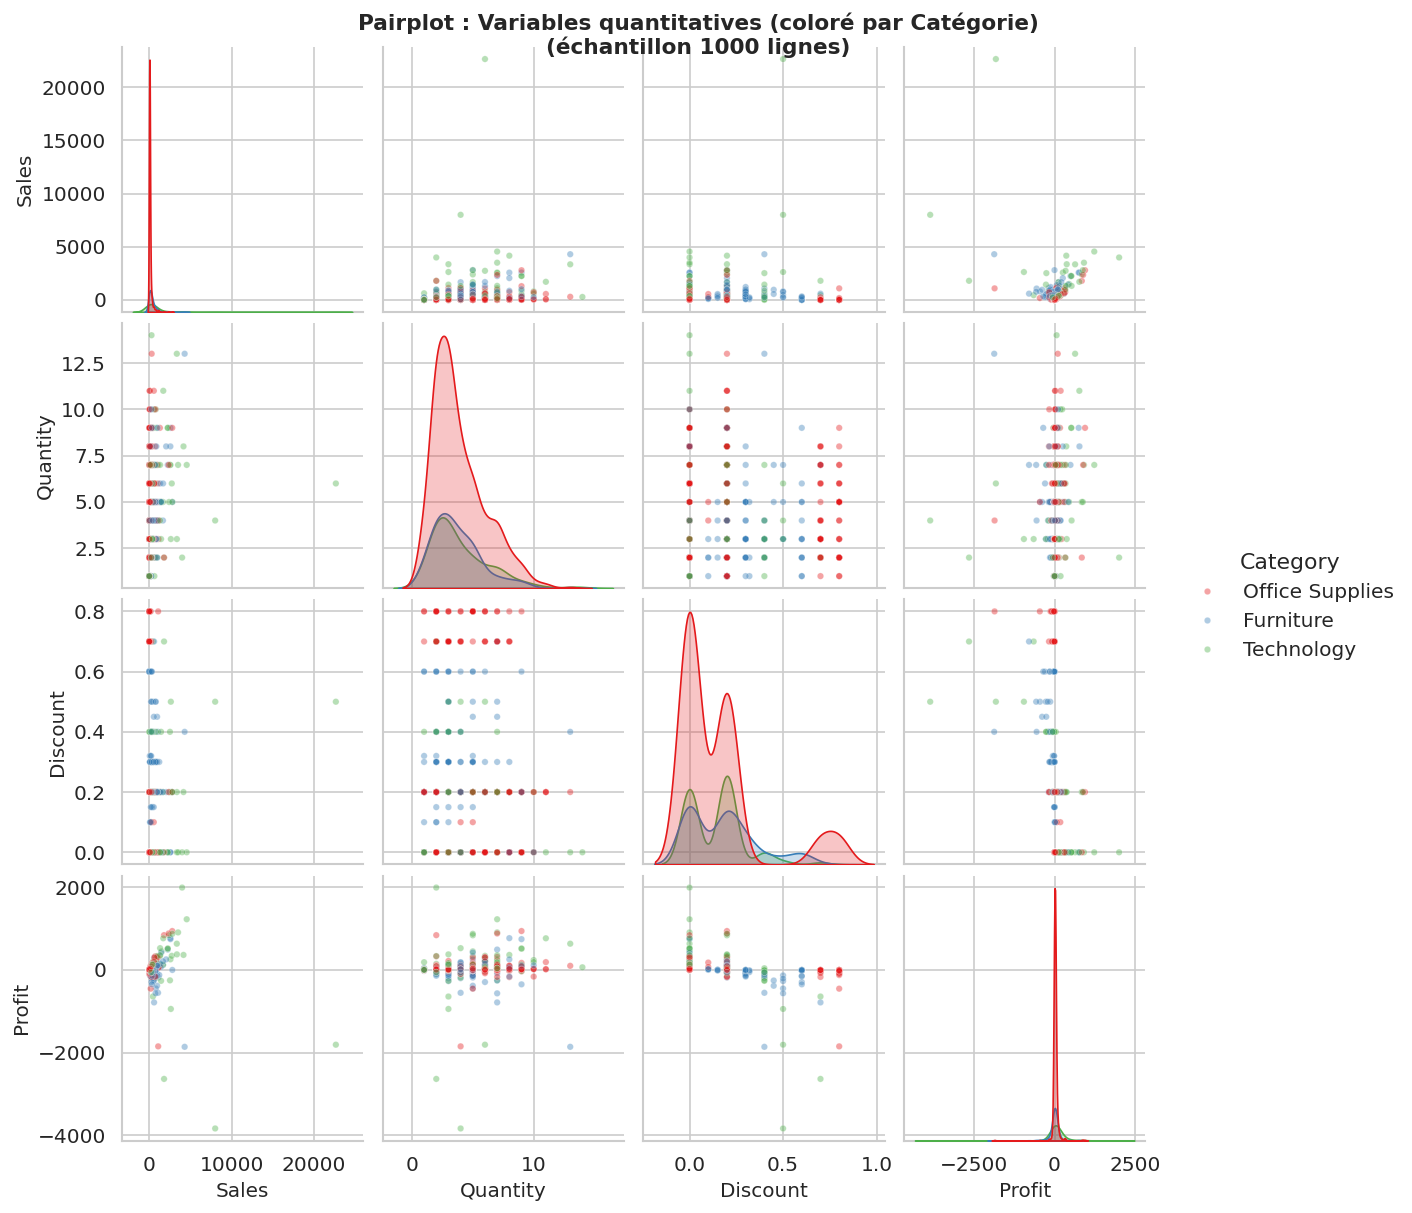

In [18]:
g = sns.pairplot(
    df[num_vars + ['Category']].sample(1000, random_state=42),  # échantillon pour la lisibilité
    hue='Category',
    palette='Set1',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde'
)
g.figure.suptitle('Pairplot : Variables quantitatives (coloré par Catégorie)\n(échantillon 1000 lignes)',
                   y=1.01, fontsize=13, fontweight='bold')
plt.savefig('fig_quantiQuanti_pairplot.png', bbox_inches='tight')
plt.show()

---
## 5. Synthèse & Recommandations Métier

In [19]:
# Tableau récapitulatif des KPIs par Région × Catégorie
summary = df.groupby(['Region', 'Category']).agg(
    Nb_commandes=('Sales', 'count'),
    Ventes_totales=('Sales', 'sum'),
    Profit_total=('Profit', 'sum'),
    Marge_pct=('Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum() * 100))
).round(2)

summary['Ventes_totales'] = summary['Ventes_totales'].map('${:,.0f}'.format)
summary['Profit_total'] = summary['Profit_total'].map('${:,.0f}'.format)
summary['Marge_pct'] = summary['Marge_pct'].map('{:.1f}%'.format)
summary

Nb_commandes Ventes_totales Profit_total Marge_pct
Region  Category                                                           
Central Furniture                 481       $163,797      $-2,871     -1.8%
        Office Supplies          1422       $167,026       $8,880      5.3%
        Technology                420       $170,416      $33,697     19.8%
East    Furniture                 601       $208,291       $3,046      1.5%
        Office Supplies          1712       $205,516      $41,015     20.0%
        Technology                535       $264,974      $47,462     17.9%
South   Furniture                 332       $117,299       $6,771      5.8%
        Office Supplies           995       $125,651      $19,986     15.9%
        Technology                293       $148,772      $19,992     13.4%
West    Furniture                 707       $252,613      $11,505      4.5%
        Office Supplies          1897       $220,853      $52,610     23.8%
        Technology                599       $251,992      $44,304     17.6%

---

## ✅ Synthèse des insights

### 🔍 Facteurs qui influencent négativement la rentabilité

| Facteur | Observation | Action recommandée |
|--------|-------------|-------------------|
| **Remises élevées (>20%)** | Corrélation négative forte avec le profit | Plafonner les remises à 20% |
| **Tables & Bookcases** | Profit total négatif malgré des ventes | Revoir la politique tarifaire ou arrêter ces références |
| **Région Central** | Profit moyen le plus faible | Analyser les coûts logistiques et les pratiques commerciales |

### 💡 Opportunités identifiées

| Opportunité | Observation | Levier |
|-------------|-------------|--------|
| **Technology** | Marge ~17%, la plus élevée | Augmenter la part des ventes Tech |
| **Région West** | Meilleure rentabilité | Répliquer les bonnes pratiques dans d'autres régions |
| **Copiers** | Sous-catégorie la plus profitable | Développer les campagnes sur ce segment |

### 📊 Relations statistiques validées

- **Discount → Profit** : relation négative significative (Pearson, p < 0.001)
- **Sales → Profit** : relation positive mais faible → le volume seul ne garantit pas la rentabilité
- La répartition régionale est homogène entre catégories → les écarts de profit sont dus aux **marges**, pas aux **volumes**

---
*Notebook réalisé dans le cadre du Projet 3 — LDA Advisory · 12 Projets pour devenir Data Analyst*